# Beamforming (Full program)

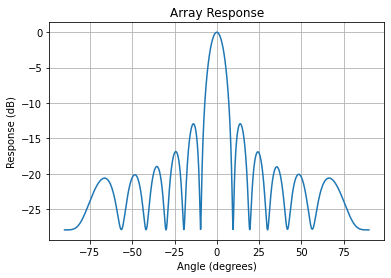

In [32]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1e6 #, 1MHz
N = 10000 # number of samples to simulate

# Create a tone to act as the transmitter signal
t = np.arange(N)/fs # time vector, (1xN), t = [0, 1/fs, 2/fs, ..., (N-1)/fs]
f = 0.02e6 # signal frequency, 20kHz

# create signal with AWG Noise
awgn = np.random.normal(0, 0.1, N) + 1j*np.random.normal(0, 0.1, N)
s_tx = np.exp(2j * np.pi * f * t) + awgn #(1xN), s_tx = [ 1, exp[i2πf/fs], ..., exp[i2πf(N-1)/fs] ]


#construct array and compute the signal steering vector
d = 0.5 # half wavelength spacing
Nr = 12
theta_degrees = 30 # direction of arrival (feel free to change this, it's arbitrary)
theta = theta_degrees / 180 * np.pi # convert from degrees to radians 

def steering_vector(theta, Nr):
    return np.exp(-2j * np.pi * d * np.arange(Nr) * np.sin(theta))# [1, exp(-2iπdsinθ), ..., exp(-2iπd(Nr-1)sinθ)], (1 x Nr) , θ = theta
#to steering_vector(theta, Nr) einai enas monodiastatos pinakas, 1D array (neither row nor column)
v_signal = steering_vector(theta, Nr)[:, None] #(Nr x 1), Column vector (2D)



#Process the signal through the array
awgn = np.random.normal(0, 0.1, (N, Nr)) + 1j*np.random.normal(0, 0.1, (N, Nr))#noise is independently applied
#mesi timi 0, σ = 0.1, gia N samples kathe keraieas
X = (s_tx[:, None] @ v_signal.T) + awgn #(N x 1) x (1 x Nr) = (N x Nr)


#v_signal.T einai o anstrofos pinakas tou v_signal
#v_signal = (Nr x 1)
#v_signal.T = (1 x Nr)
#to .T den mporei na efarmostei sto steering_vector(theta, Nr) giati den einai 2D
#s_tx[:, None] einai (N x 1)
# Ara X is (N x Nr)



thetas = np.arange(-90, 90, 0.1)#(1x1800)

outputs = []
responses = []
for theta in thetas:
    theta *= np.pi/180
    w = steering_vector(theta, Nr)[:, None]#w = (Nr x 1)
    y = (X @ w.conj()) / Nr #power we received at each angle. , y = (N x 1)
    response = 10*np.log10(np.var(y))#, in dB

    outputs.append(y)#.append(y) adds the variable y to the list outputs.
    responses.append(response)#.append(response) adds the variable y to the list responses.
   
responses -= np.max(responses)#oste 0 dB na einai to maximum response 
#w.conj() einai to siziges



angle_idx = np.argmax(responses)#finds the index of the maximum response 
aoa = thetas[angle_idx]#retrieve the corresponding angle from thetas array
s_hat = outputs[angle_idx]#is the signal y that was previously computed at that best direction.

plt.plot(thetas, responses)
plt.grid();
plt.title("Array Response")
plt.xlabel("Angle (degrees)")
plt.ylabel("Response (dB)");
plt.show()
   

# Real and Imag part of the transmitted signal

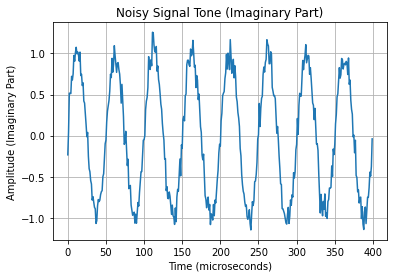

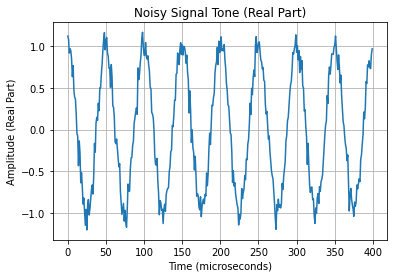

In [6]:
### import numpy as np
import matplotlib.pyplot as plt

fs = 1e6 #, 1MHz
N = 10000 # number of samples to simulate

# Create a tone to act as the transmitter signal
t = np.arange(N)/fs # time vector, (1xN), t = [0, 1/fs, 2/fs, ..., (N-1)/fs]
f = 0.02e6 # signal frequency, 20kHz

# create signal with AWG Noise
awgn = np.random.normal(0, 0.1, N) + 1j*np.random.normal(0, 0.1, N)
s_tx = np.exp(2j * np.pi * f * t) + awgn #(1xN), s_tx = [1, exp[i2πf/fs], ..., exp[i2πf(N-1)/fs] ]
#kanw plot real kai imag part gia to transmit signal
# Real kai Imag part tou ekpempomenou signal
plt.figure(1)
plt.plot(s_tx[:400].imag) #Selects the first 400 samples of the signal.Και επιλεγει το imaginary part
plt.title("Noisy Signal Tone (Imaginary Part)")
plt.xlabel("Time (microseconds)")
plt.ylabel("Amplitude (Imaginary Part)")
plt.grid()  

plt.figure(2)
plt.plot(s_tx[:400].real) #Selects the first 400 real samples of the signal. Και επιλεγει το real part
plt.title("Noisy Signal Tone (Real Part)")
plt.xlabel("Time (microseconds)")
plt.ylabel("Amplitude (Real Part)")
plt.grid()
                   
plt.show()

# Rows x Columns

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1e6 #, 1MHz
N = 10000 # number of samples to simulate

# Create a tone to act as the transmitter signal
t = np.arange(N)/fs # time vector, (1xN), t = [0, 1/fs, 2/fs, ..., (N-1)/fs]
f = 0.02e6 # signal frequency, 20kHz

# create signal with AWG Noise
awgn = np.random.normal(0, 0.1, N) + 1j*np.random.normal(0, 0.1, N)
s_tx = np.exp(2j * np.pi * f * t) + awgn

d = 0.5 # half wavelength spacing
Nr = 2
theta_degrees = 30 # direction of arrival (feel free to change this, it's arbitrary)
theta = theta_degrees / 180 * np.pi

def steering_vector(theta, Nr):
    return np.exp(-2j * np.pi * d * np.arange(Nr) * np.sin(theta))# (1 x Nr), [1, exp(-2iπdsinθ), ..., exp(-2iπd(Nr-1)sinθα)], θ = theta
#to steering_vector(theta, Nr) einai enas monodiastatos pinakas, 1D array (neither row nor column)
v_signal = steering_vector(theta, Nr)[:, None] #Column vector (2D)

awgn = np.random.normal(0, 0.1, (N, Nr)) + 1j*np.random.normal(0, 0.1, (N, Nr))
X = (s_tx[:, None] @ v_signal.T) + awgn

print("s_tx[:, None]=",s_tx[:, None].shape)
print("s_tx[None, :]=",s_tx[None, :].shape)
print("v_signal.T=",v_signal.T.shape)
print("X=",X.shape)


s_tx[:, None]= (10000, 1)
s_tx[None, :]= (1, 10000)
v_signal.T= (1, 2)
X= (10000, 2)


# Lamvanwn signal (X)

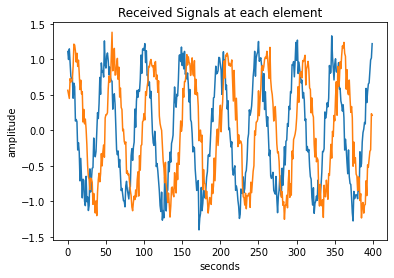

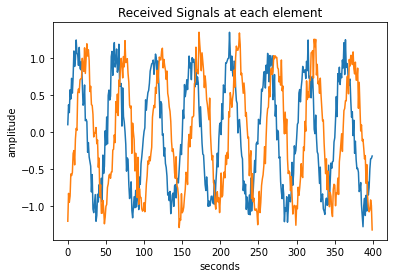

In [14]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1e6 
N = 10000 

# Create a tone to act as the transmitter signal
t = np.arange(N)/fs 
f = 0.02e6 

# create signal with AWG Noise
awgn = np.random.normal(0, 0.1, N) + 1j*np.random.normal(0, 0.1, N)
s_tx = np.exp(2j * np.pi * f * t) + awgn 


#construct array and compute the signal steering vector
d = 0.5 
Nr = 2
theta_degrees = 30
theta = theta_degrees / 180 * np.pi 

def steering_vector(theta, Nr):
    return np.exp(-2j * np.pi * d * np.arange(Nr) * np.sin(theta))

v_signal = steering_vector(theta, Nr)[:, None] 

awgn = np.random.normal(0, 0.1, (N, Nr)) + 1j*np.random.normal(0, 0.1, (N, Nr))
X = (s_tx[:, None] @ v_signal.T) + awgn

#Lamvanon signal kathe keraias
plt.figure(3)
plt.plot(np.real(X[0:400, :]), label=[f"in phase element {i}" for i in range(Nr)]);   #I
plt.title("Received Signals at each element")
plt.xlabel("seconds")
plt.ylabel("amplitude");

plt.figure(4)
plt.plot(np.imag(X[0:400, :]), label=[f"quadrature element {i}" for i in range(Nr)]);  #Q
plt.title("Received Signals at each element")
plt.xlabel("seconds")
plt.ylabel("amplitude");

plt.show()

'''
theta = π/6
with blue i see the cos(xi) and sin(xi) me i=0 eos N-1 and with orange i see cos(xi - π/2) for real and sin(xi - π/2)
Re{X}  
          1        ,            0
       cos(2πf/fs) , cos(2πf/fs - π/2)
         .         ,            .           
         .         ,            .  
         .         ,            . 
  cos(2π(N-1)f/fs) , cos(2π(N-1)f/fs - π/2)
  
'''

# Y for theta = -30 kai Nr = 2

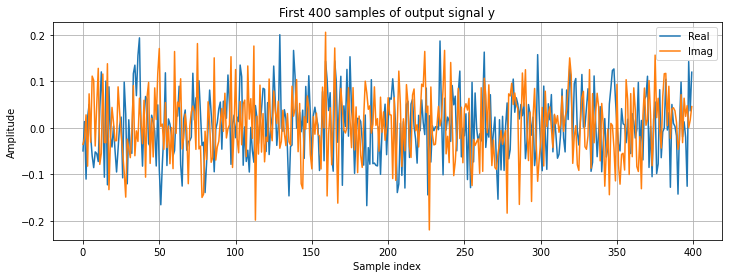

In [30]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1e6 #, 1MHz
N = 10000 # number of samples to simulate

# Create a tone to act as the transmitter signal
t = np.arange(N)/fs # time vector, (1xN), t = [0, 1/fs, 2/fs, ..., (N-1)/fs]
f = 0.02e6 # signal frequency, 20kHz

# create signal with AWG Noise
awgn = np.random.normal(0, 0.1, N) + 1j*np.random.normal(0, 0.1, N)
s_tx = np.exp(2j * np.pi * f * t) + awgn #(1xN), s_tx = [ 1, exp[i2πf/fs], ..., exp[i2πf(N-1)/fs] ]


#construct array and compute the signal steering vector
d = 0.5 # half wavelength spacing
Nr = 2
theta_degrees = 30 # direction of arrival (feel free to change this, it's arbitrary)
theta = theta_degrees / 180 * np.pi # convert from degrees to radians 

def steering_vector(theta, Nr):
    return np.exp(-2j * np.pi * d * np.arange(Nr) * np.sin(theta))# [1, exp(-2iπdsinθ), ..., exp(-2iπd(Nr-1)sinθ)], (1 x Nr) , θ = theta
#to steering_vector(theta, Nr) einai enas monodiastatos pinakas, 1D array (neither row nor column)
v_signal = steering_vector(theta, Nr)[:, None] #(Nr x 1), Column vector (2D)



#Process the signal through the array
awgn = np.random.normal(0, 0.1, (N, Nr)) + 1j*np.random.normal(0, 0.1, (N, Nr))#noise is independently applied
#mesi timi 0, σ = 0.1, gia N samples kathe keraieas
X = (s_tx[:, None] @ v_signal.T) + awgn

outputs = []
responses = []

w = steering_vector(-np.pi/6, Nr)[:, None]#esto oti psaxnoume sti gonia -π/6 (-30 moires)
y = (X @ w.conj()) / Nr
response = 10*np.log10(np.var(y))
outputs.append(y)
responses.append(response)


plt.figure(figsize=(12, 4))
plt.plot(np.real(y[:400]), label='Real')
plt.plot(np.imag(y[:400]), label='Imag')
plt.title("First 400 samples of output signal y")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()
#kserontas idi oti konta sto -30 moires i apokrish einai xamili, me auto to graphima epivevaionetai.
